In [4]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time
import warnings
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from itertools import cycle

warnings.filterwarnings("ignore")

BATCH_SIZE = 64
NUM_WORKERS = 0 
EPOCHS = 5

MEVCUT_KONUM = r"C:\Users\efeya\Desktop\Dönem Projeleri\Derin Öğrenme\Benimki"
DATA_PATH = os.path.join(MEVCUT_KONUM, 'train')
CSV_PATH = os.path.join(MEVCUT_KONUM, 'imdb_top_1000.csv')

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Kullanılıyor: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CPU Kullanılıyor")

GPU Kullanılıyor: NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if not os.path.exists(DATA_PATH):
    print(f"HATA: Veri klasörü bulunamadı: {DATA_PATH}")
else:
    full_dataset = datasets.ImageFolder(DATA_PATH, transform=data_transforms)
    class_names = full_dataset.classes
    print(f"Sınıflar: {class_names}")

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                            num_workers=NUM_WORKERS, pin_memory=True)
    print("Veri setleri yüklendi.")

Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Veri setleri yüklendi.


In [6]:
model = models.densenet121(weights=None)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(class_names))
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler('cuda')
print("DenseNet121 Base Modeli Hazır.")

DenseNet121 Base Modeli Hazır.


In [7]:
train_acc_hist, val_acc_hist = [], []
train_loss_hist, val_loss_hist = [], []

print(f"Eğitim başlıyor... Toplam {EPOCHS} Epoch.")
global_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
    
    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects.double() / len(val_dataset)
    
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Time: {epoch_time:.1f}s | Train Loss: {epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")
    
    train_acc_hist.append(epoch_acc.item())
    val_acc_hist.append(val_epoch_acc.item())
    train_loss_hist.append(epoch_loss)
    val_loss_hist.append(val_epoch_loss)
print("Eğitim tamamlandı.")

Eğitim başlıyor... Toplam 5 Epoch.
Epoch 1/5 | Time: 148.7s | Train Loss: 1.6960 | Val Loss: 1.6819 | Train Acc: 0.3125 | Val Acc: 0.3760
Epoch 2/5 | Time: 148.5s | Train Loss: 1.3983 | Val Loss: 1.3626 | Train Acc: 0.4592 | Val Acc: 0.4859
Epoch 3/5 | Time: 154.1s | Train Loss: 1.2509 | Val Loss: 1.2490 | Train Acc: 0.5177 | Val Acc: 0.5298
Epoch 4/5 | Time: 151.5s | Train Loss: 1.1599 | Val Loss: 1.1748 | Train Acc: 0.5569 | Val Acc: 0.5563
Epoch 5/5 | Time: 152.6s | Train Loss: 1.0818 | Val Loss: 1.1988 | Train Acc: 0.5905 | Val Acc: 0.5458
Eğitim tamamlandı.


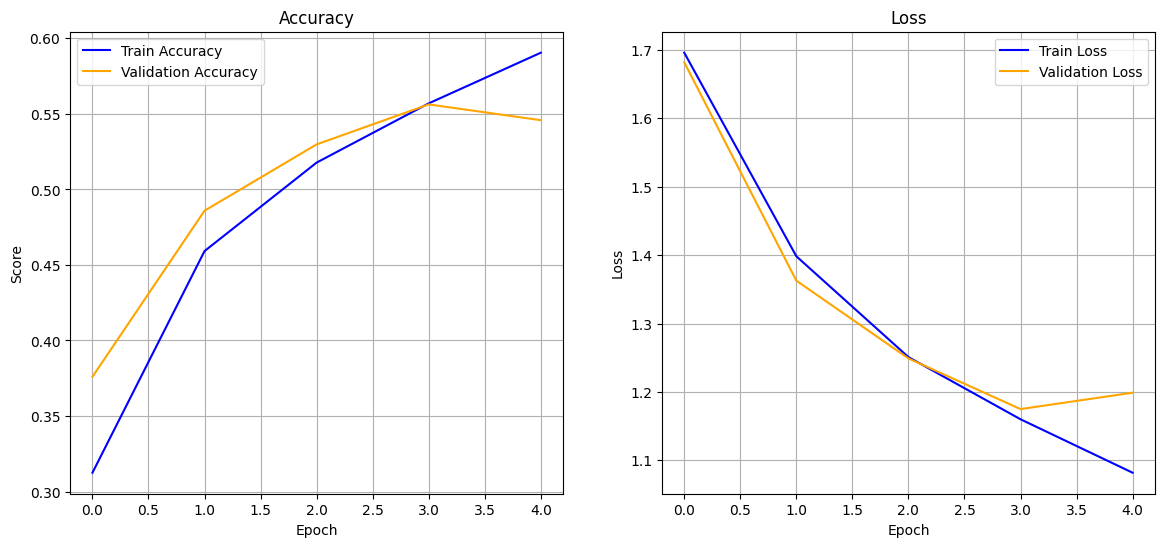

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(train_acc_hist, label='Train Accuracy', color='blue')
plt.plot(val_acc_hist, label='Validation Accuracy', color='orange')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss_hist, label='Train Loss', color='blue')
plt.plot(val_loss_hist, label='Validation Loss', color='orange')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [9]:
print("Detaylı metrikler hesaplanıyor...")
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
print("Veriler hazır.")

Detaylı metrikler hesaplanıyor...
Veriler hazır.


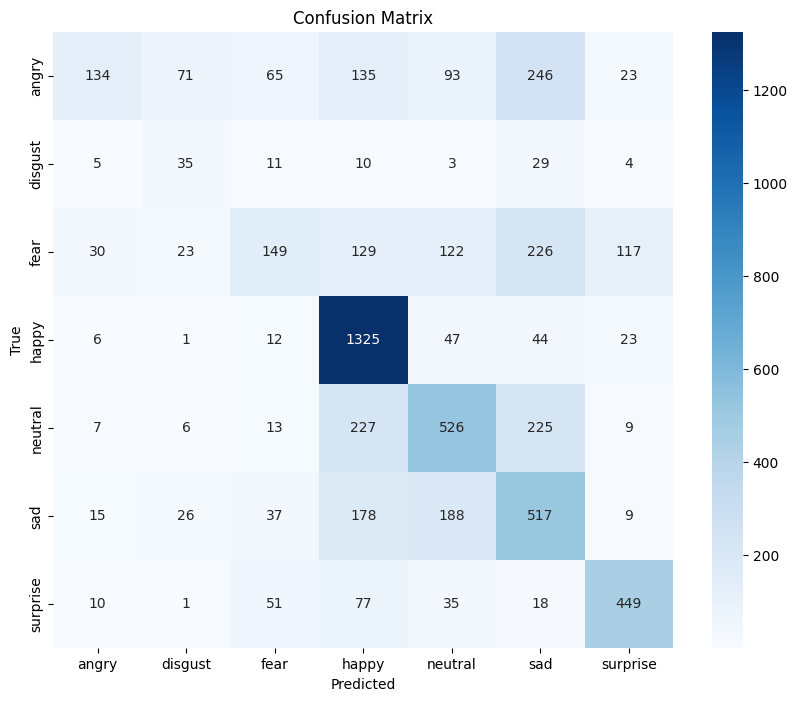

              precision    recall  f1-score   support

       angry       0.65      0.17      0.28       767
     disgust       0.21      0.36      0.27        97
        fear       0.44      0.19      0.26       796
       happy       0.64      0.91      0.75      1458
     neutral       0.52      0.52      0.52      1013
         sad       0.40      0.53      0.45       970
    surprise       0.71      0.70      0.70       641

    accuracy                           0.55      5742
   macro avg       0.51      0.48      0.46      5742
weighted avg       0.55      0.55      0.51      5742



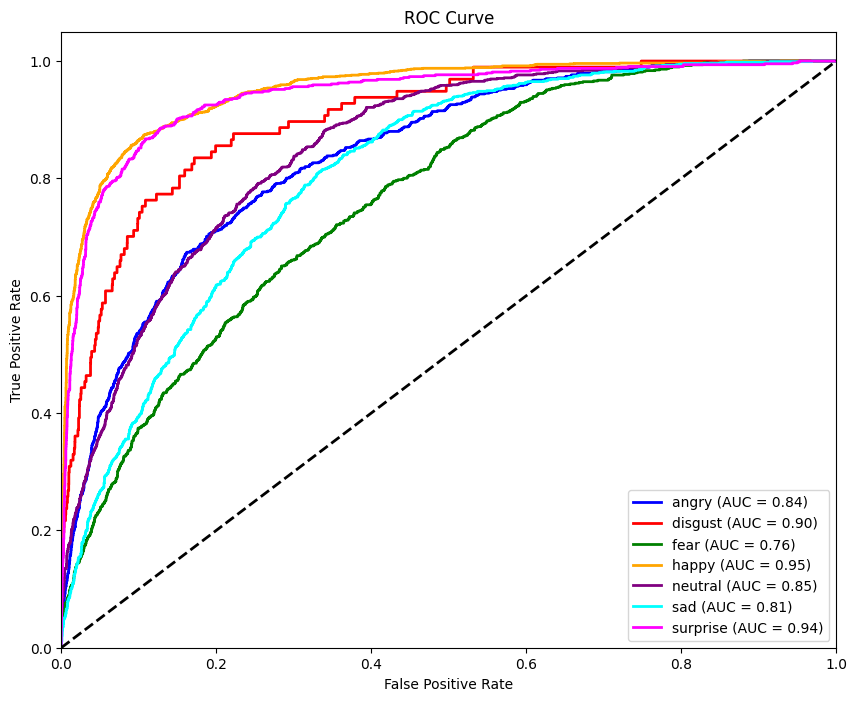

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print(classification_report(all_labels, all_preds, target_names=class_names))

y_test_bin = label_binarize(all_labels, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

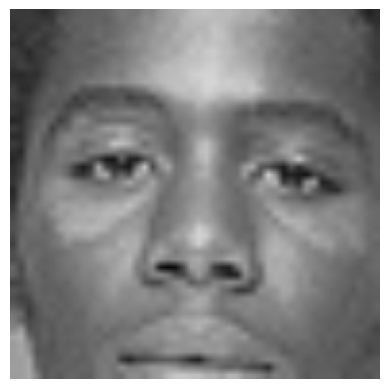

Gerçek: neutral
Tahmin: neutral
------------------------------
Duygu: NEUTRAL -> Öneri: Solaris (1972) [Drama]


In [20]:
def recommend_movie(emotion):
    try:
        if not os.path.exists(CSV_PATH): return "CSV dosyası bulunamadı."
        df = pd.read_csv(CSV_PATH)
        genre_map = {'angry': 'Action', 'disgust': 'Horror', 'fear': 'Thriller',
                     'happy': 'Comedy', 'neutral': 'Drama', 'sad': 'Romance', 'surprise': 'Sci-Fi'}
        
        target_genre = 'Drama'
        for key, value in genre_map.items():
            if key in emotion.lower():
                target_genre = value
                break
                
        filt = df[df['Genre'].astype(str).str.contains(target_genre, case=False, na=False)]
        if not filt.empty:
            m = filt.sample(1).iloc[0]
            return f"Duygu: {emotion.upper()} -> Öneri: {m['Series_Title']} ({m['Released_Year']}) [{target_genre}]"
        return "Film bulunamadı."
    except Exception as e: return f"Hata: {e}"

if len(val_dataset) > 0:
    rnd_idx = np.random.randint(0, len(val_dataset))
    img, label = val_dataset[rnd_idx]
    
    gorsel = img.permute(1, 2, 0).cpu().numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    plt.imshow(np.clip(gorsel, 0, 1))
    plt.axis('off')
    plt.show()
    
    model.eval()
    with torch.no_grad():
        pred_idx = model(img.unsqueeze(0).to(device)).argmax(1).item()
        
    print(f"Gerçek: {class_names[label]}")
    print(f"Tahmin: {class_names[pred_idx]}")
    print("-" * 30)
    print(recommend_movie(class_names[pred_idx]))